In [1]:
%load_ext autoreload
%autoreload 2
import pandas as pd
from src.config import *
from src.utils import *
from src.feature_extraction import *

In [2]:
gt_subset = pd.read_csv(BINARY_GT_TRAIN_SUBSET_CSV)
sample = gt_subset.groupby("label").sample(500, random_state=RANDOM_STATE)

rows = []
for r in sample.itertuples():
    img = load_preprocessed(r.filename, r.label, BINARY_PREPROC_TRAIN_DIR)
    rows.append({"filename": r.filename, "label": r.label, **extract_features(img)})

df = pd.DataFrame(rows)
df.shape    # should be (1000, 232)

(1000, 232)

#### Exploring some feature ranges

In [13]:
pixels = {"hsv_s": [], "lab_a": [], "lab_b": []}

for r in gt_subset.sample(200, random_state=RANDOM_STATE).itertuples():
    img = load_preprocessed(r.filename, r.label, BINARY_PREPROC_TRAIN_DIR)
    hsv = cv2.cvtColor(img, cv2.COLOR_RGB2HSV)
    lab = cv2.cvtColor(img, cv2.COLOR_RGB2LAB)
    pixels["hsv_s"].append(hsv[:, :, 1].ravel()[::50])   # every 50th pixel
    pixels["lab_a"].append(lab[:, :, 1].ravel()[::50])
    pixels["lab_b"].append(lab[:, :, 2].ravel()[::50])

for channel, values in pixels.items():
    low, high = np.percentile(np.concatenate(values), [1, 99])
    print(f"{channel}: {low:.0f} - {high:.0f}")

hsv_s: 1 - 159
lab_a: 120 - 157
lab_b: 117 - 155


In [3]:
feature_groups = {
    "color_moments": [c for c in df.columns if c.startswith(("rgb_", "hsv_", "lab_"))],
    "color_hist":    [c for c in df.columns if c.startswith("hist_")],
    "lbp":           [c for c in df.columns if c.startswith("lbp_")],
    "glcm":          [c for c in df.columns if c.startswith("glcm_")],
}
for name, cols in feature_groups.items():
    print(f"{name}: {len(cols)} features")

color_moments: 36 features
color_hist: 96 features
lbp: 80 features
glcm: 18 features


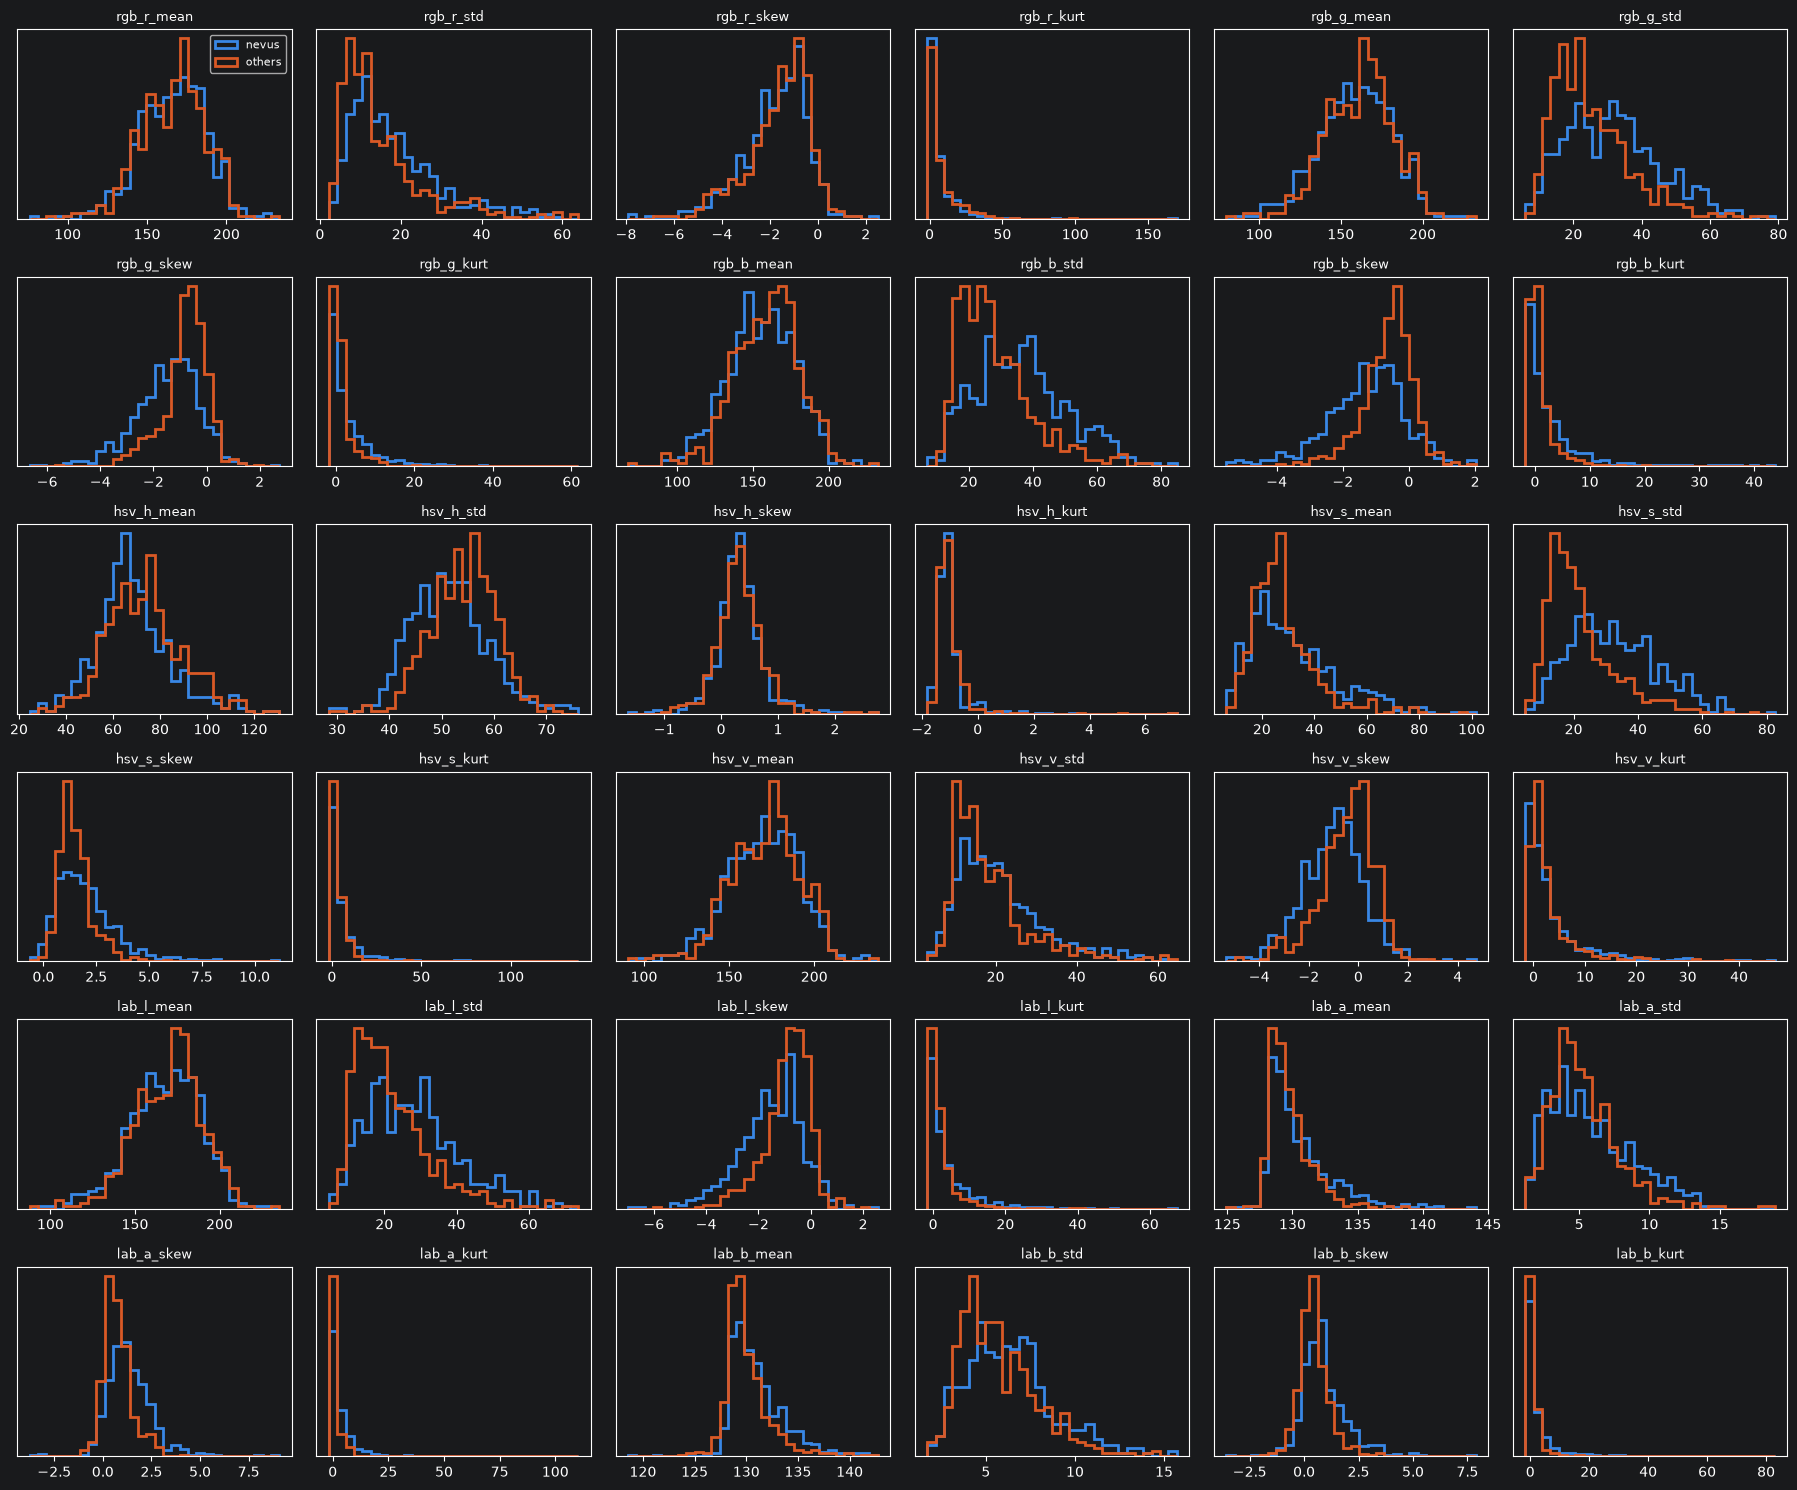

In [5]:
plot_feature_distributions(df, feature_groups["color_moments"])

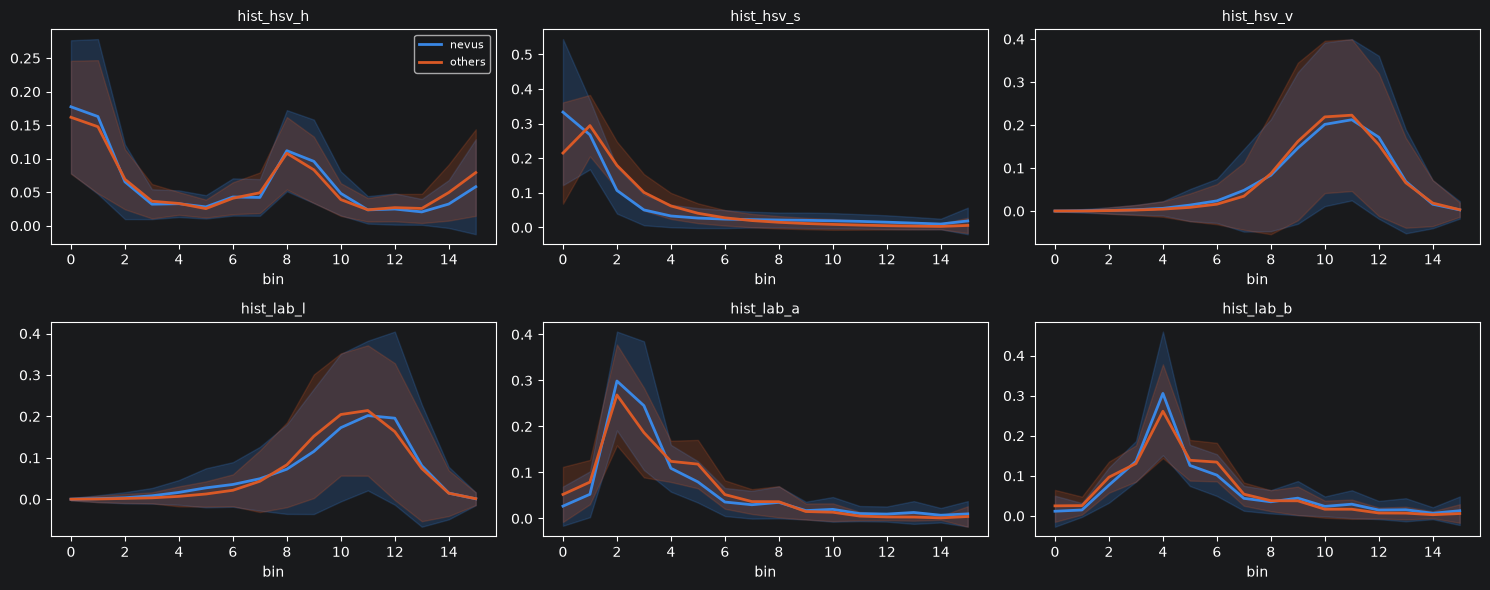

In [6]:
plot_mean_histograms(df, ["hist_hsv_h_", "hist_hsv_s_", "hist_hsv_v_",
                          "hist_lab_l_", "hist_lab_a_", "hist_lab_b_"])

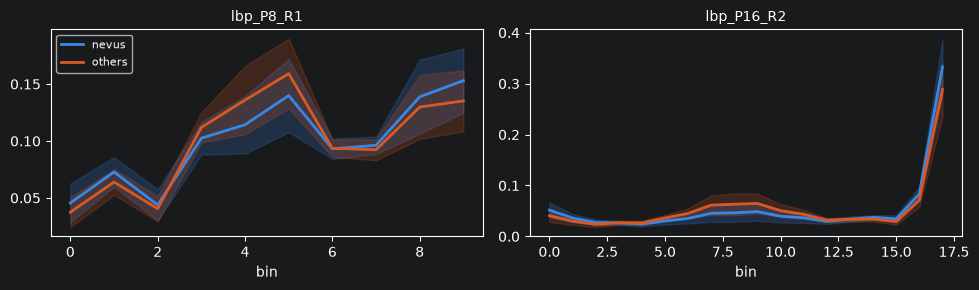

In [7]:
plot_mean_histograms(df, ["lbp_P8_R1_", "lbp_P16_R2_"], ncols=2)

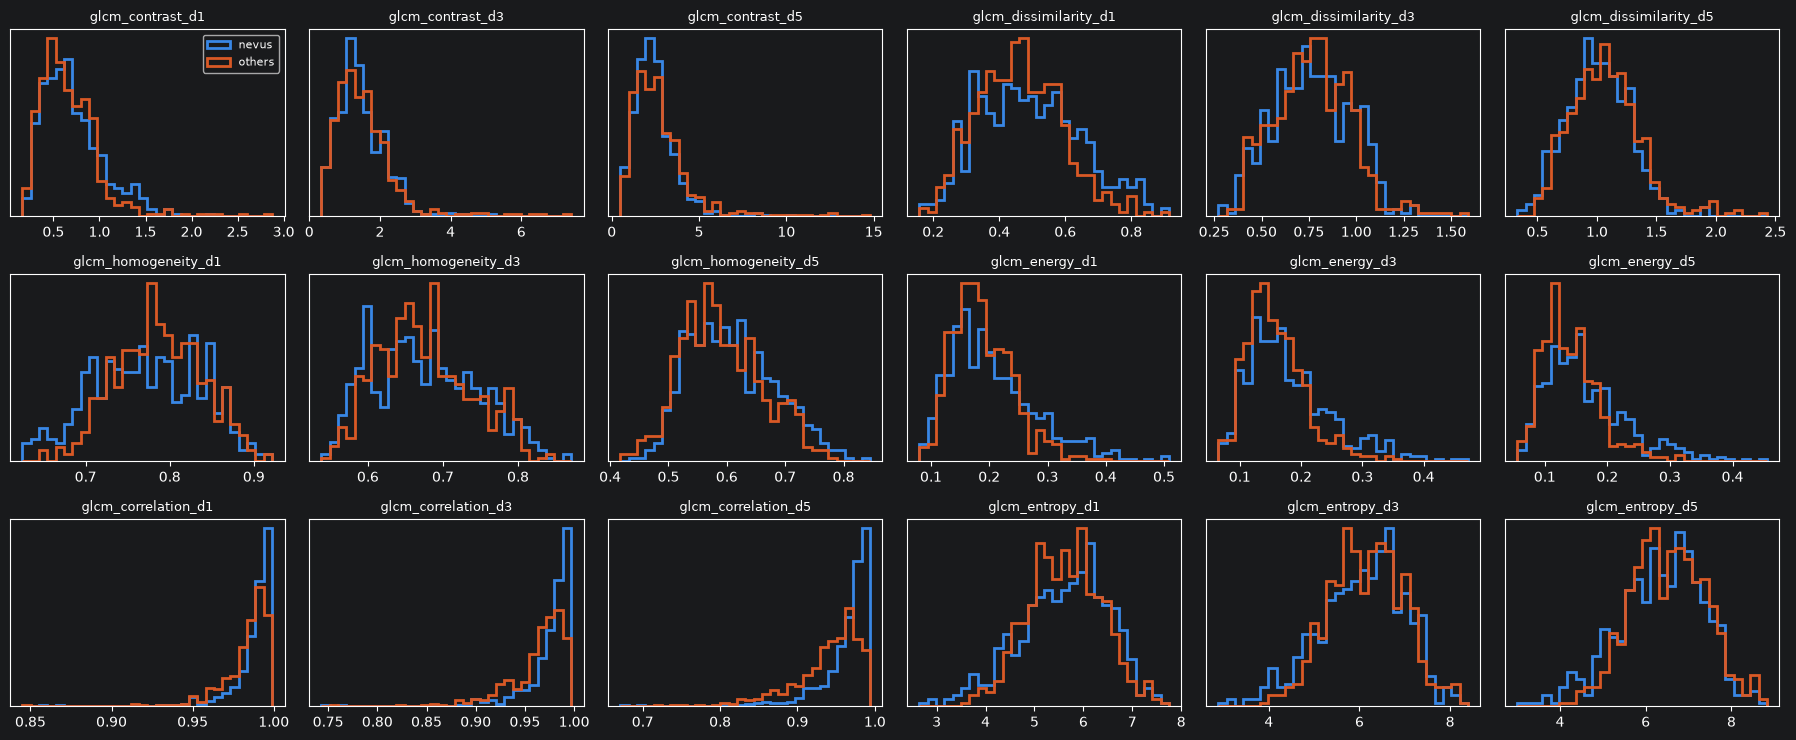

In [8]:
plot_feature_distributions(df, feature_groups["glcm"])

#### Explore how good is each feature at separating the two classes

In [9]:
from sklearn.metrics import roc_auc_score

feature_cols = [c for c in df.columns if c not in ("filename", "label")]
auc = pd.Series({c: roc_auc_score(df["label"], df[c]) for c in feature_cols})

# Distance from 0.5 = separation power, whatever the direction
separation = (auc - 0.5).abs().sort_values(ascending=False)
separation.head(40)

lbp_P24_R5_5     0.297748
lbp_P24_R5_6     0.295920
hist_hsv_s_3     0.282606
lbp_P24_R3_7     0.280124
lbp_P24_R5_7     0.278110
lbp_P24_R5_4     0.277220
hist_hsv_s_2     0.274380
lbp_P24_R3_8     0.271526
lbp_P24_R3_6     0.268184
lbp_P16_R2_6     0.260820
lbp_P24_R5_8     0.259996
lbp_P24_R3_9     0.259032
lbp_P16_R2_5     0.258512
lbp_P24_R5_18    0.256786
lbp_P16_R2_16    0.256778
lbp_P24_R3_1     0.252730
hist_hsv_s_4     0.249938
lbp_P24_R5_19    0.246478
hsv_s_std        0.246172
hist_hsv_s_11    0.245742
hist_hsv_s_12    0.245114
lbp_P24_R3_10    0.244712
lbp_P24_R3_24    0.243432
lbp_P24_R5_1     0.242810
lbp_P16_R2_7     0.240726
lbp_P24_R5_17    0.239958
lbp_P16_R2_1     0.237560
lbp_P24_R3_16    0.237094
lbp_P16_R2_8     0.236118
lbp_P16_R2_10    0.235016
hist_hsv_s_13    0.234582
lbp_P24_R5_9     0.233680
lbp_P24_R5_25    0.233664
lbp_P24_R3_25    0.232996
lbp_P16_R2_9     0.232808
lbp_P24_R3_22    0.230384
lbp_P24_R3_5     0.229328
lbp_P24_R5_23    0.229154
lbp_P16_R2_1

In [10]:
for name, cols in feature_groups.items():
    print(f"{name:15s} best: {separation[cols].max():.3f}   mean: {separation[cols].mean():.3f}")

color_moments   best: 0.246   mean: 0.090
color_hist      best: 0.283   mean: 0.094
lbp             best: 0.298   mean: 0.198
glcm            best: 0.212   mean: 0.065


#### PCA of the features

In [11]:
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

df = df.drop(columns="is_600x450", errors="ignore")
feature_cols = [c for c in df.columns if c not in ("filename", "label")]

X = StandardScaler().fit_transform(df[feature_cols])
pca = PCA(n_components=3)
X_pca = pca.fit_transform(X)

print("Explained variance per component:", pca.explained_variance_ratio_.round(3))
print("Total (3 components):", pca.explained_variance_ratio_.sum().round(3))

Explained variance per component: [0.259 0.154 0.078]
Total (3 components): 0.49


In [12]:
import plotly.express as px

pca_df = pd.DataFrame(X_pca, columns=["PC1", "PC2", "PC3"])
pca_df["class"] = df["label"].map(CLASS_NAMES).values
pca_df["filename"] = df["filename"].values

fig = px.scatter_3d(
    pca_df, x="PC1", y="PC2", z="PC3",
    color="class",
    color_discrete_map={CLASS_NAMES[k]: v for k, v in CLASS_COLORS.items()},
    hover_data=["filename"],
    opacity=0.7,
)
fig.update_traces(marker=dict(size=4))
fig.show()

The PCA plot shows that the two classes are not linearly separable in the feature space, but there is some clustering of the two classes.